In [47]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import roc_auc_score

# -------------------- FAST DELONG CODE -------------------- #
def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5*(i + j - 1)
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T + 1
    return T2

def fastDeLong_no_weights(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)
    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov

def delong_roc_variance(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    assert set(np.unique(y_true)) == {0, 1}, "y_true must be binary (0,1)"

    order = np.argsort(-y_true)
    y_true = y_true[order]
    y_pred = y_pred[order]
    label_1_count = int(np.sum(y_true))

    predictions_sorted_transposed = y_pred[np.newaxis, :]
    aucs, auc_cov = fastDeLong_no_weights(predictions_sorted_transposed, label_1_count)
    return aucs[0], auc_cov
# ---------------------------------------------------------- #



<mark>XGBOOST</mark>

Zahra/XGboost_OOT/MD/ARF/Evaluate

--------------
OOT

Zahra/CoreBehrt_OOT/MD/5_Evaluate/Mortality/Predictions

In [68]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from azureml.core import Workspace, Dataset, Datastore
from io import BytesIO
import tempfile
import os
from azureml.core import Workspace, Dataset, Datastore

subscription_id = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
resource_group = 'forskerpl-n0ybkr-rg'
workspace_name = 'forskerpl-n0ybkr-mlw'

workspace = Workspace(subscription_id, resource_group, workspace_name)
datastore = Datastore.get(workspace, "researcher_data")

# تعریف Dataset از مسیر
dataset = Dataset.File.from_files(path=(datastore,'Zahra/XGboost_OOT/MD/PRI/Evaluate/predictions.csv'))   

# دانلود فایل به صورت local
download_path = './temp_downloaded'
dataset.download(target_path=download_path, overwrite=True)

# پیدا کردن فایل predictions.csv در دایرکتوری
file_path = None
for root, dirs, files in os.walk(download_path):
    for file in files:
        if file == 'predictions.csv':
            file_path = os.path.join(root, file)

# خواندن CSV با pandas
if file_path:
    df = pd.read_csv(file_path)
    print(df.head())
else:
    print("Not found")


{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
    pid  target  fold_1_probas  fold_2_probas  fold_3_probas  fold_4_probas  \
0    45       0       0.232497       0.430968       0.439730       0.278831   
1  3555       0       0.065691       0.073761       0.113798       0.109984   
2  3915       0       0.556154       0.666605       0.640500       0.725101   
3  6210       0       0.399672       0.661973       0.507256       0.589780   
4  6615       0       0.775729       0.751658       0.793045       0.614314   

   fold_5_probas  
0       0.360987  
1       0.155431  
2       0.697610  
3       0.634638  
4       0.690311  


In [69]:
fold_cols = [f"fold_{i}_probas" for i in range(1, 6)]
y_true = df["target"].values
for fold_col in fold_cols:
    y_pred = df[fold_col].values

    auc, auc_cov = delong_roc_variance(y_true, y_pred)


    if isinstance(auc_cov, np.ndarray):
        auc_var = auc_cov[0][0]
    else:
        auc_var = auc_cov

    auc_std = np.sqrt(auc_var)

    # 95% confidence interval
    z = stats.norm.ppf(0.975)  # 1.96
    lower = max(0.0, auc - z * auc_std)
    upper = min(1.0, auc + z * auc_std)

    print(f"{fold_col}: AUC = {auc:.4f} ± {auc_std:.4f} | 95% CI: [{lower:.4f}, {upper:.4f}]")


fold_1_probas: AUC = 0.7896 ± 0.0168 | 95% CI: [0.7568, 0.8225]
fold_2_probas: AUC = 0.7872 ± 0.0155 | 95% CI: [0.7568, 0.8176]
fold_3_probas: AUC = 0.7776 ± 0.0157 | 95% CI: [0.7469, 0.8083]
fold_4_probas: AUC = 0.7855 ± 0.0160 | 95% CI: [0.7543, 0.8168]
fold_5_probas: AUC = 0.7983 ± 0.0150 | 95% CI: [0.7688, 0.8278]


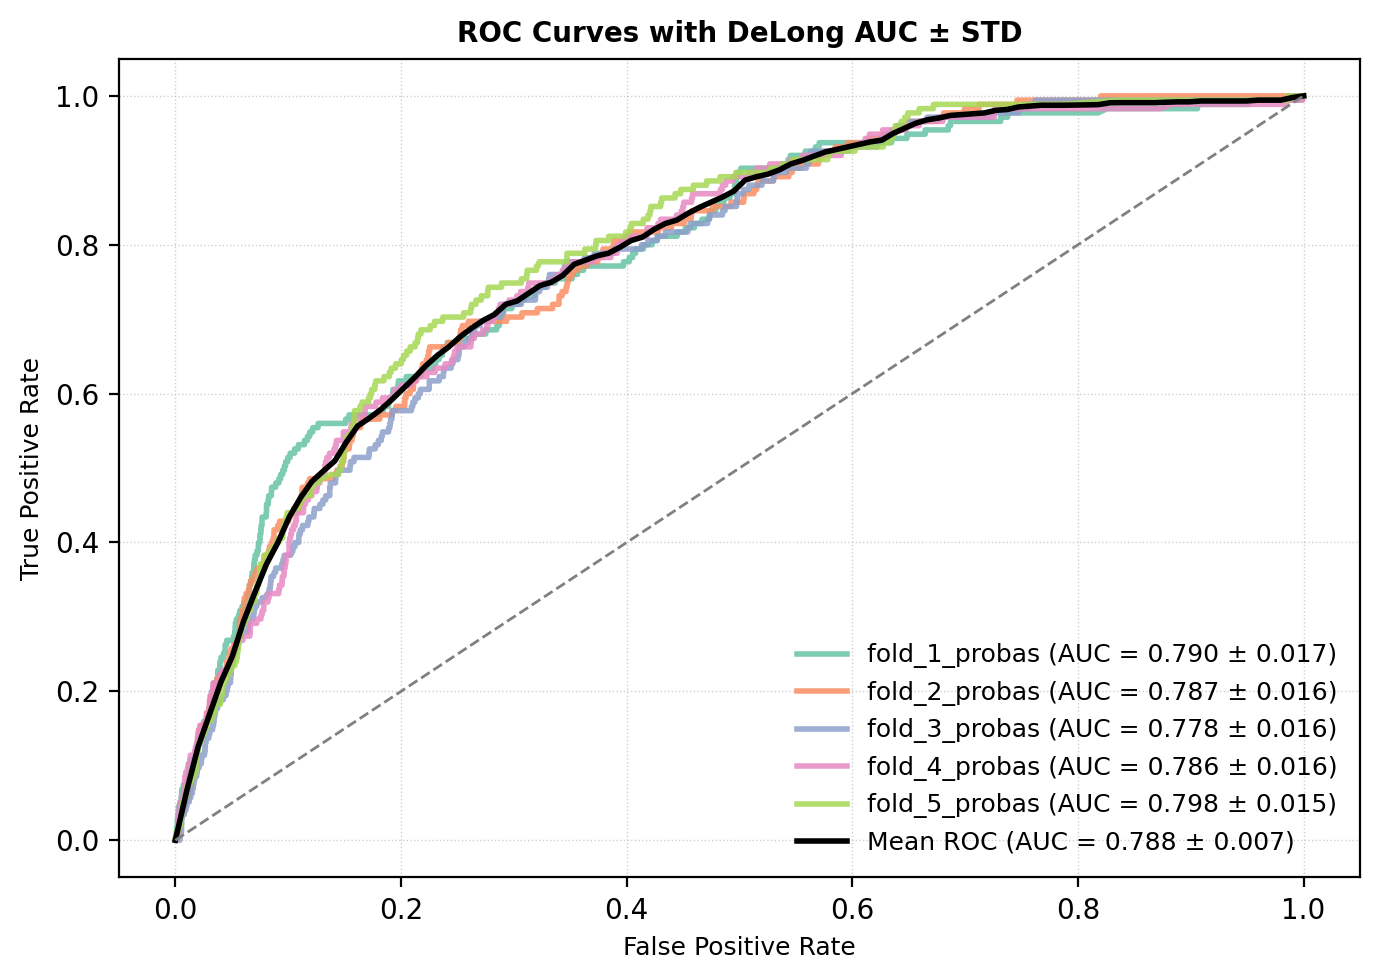

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from scipy import stats

# ستون‌های مربوط به فولدها
fold_cols = [f"fold_{i}_probas" for i in range(1, 6)]
y_true = df["target"].values

# محور FPR برای ROC و Recall برای PR
mean_fpr = np.linspace(0, 1, 100)
mean_recall = np.linspace(0, 1, 100)

# رنگ‌ها برای هر fold
colors = sns.color_palette("Set2", n_colors=len(fold_cols))

# ===  ROC CURVE === #
tprs = []
mean_auc_list = []

plt.figure(figsize=(7, 5), dpi=200)

for i, fold_col in enumerate(fold_cols):
    y_pred = df[fold_col].values
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)

    # DeLong uncertainty
    auc_delong, auc_cov = delong_roc_variance(y_true, y_pred)
    auc_var = auc_cov[0][0] if isinstance(auc_cov, np.ndarray) else auc_cov
    auc_std = np.sqrt(auc_var)

    mean_auc_list.append(roc_auc)

    # TPR interpolate
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    label = f"{fold_col} (AUC = {auc_delong:.3f} ± {auc_std:.3f})"
    plt.plot(fpr, tpr, lw=2, alpha=0.85, color=colors[i], label=label)

mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
mean_tpr[-1] = 1.0

mean_auc = np.mean(mean_auc_list)
std_auc = np.std(mean_auc_list)

plt.plot(mean_fpr, mean_tpr, color='black', lw=2,
         label=f"Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})")

#plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
            #    color='gray', alpha=0.2, label="Mean TPR ±1 STD")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)
plt.xlabel("False Positive Rate", fontsize=9)
plt.ylabel("True Positive Rate", fontsize=9)
plt.title("ROC Curves with DeLong AUC ± STD", fontsize=10, fontweight='bold')
plt.grid(True, linestyle=':', linewidth=0.5, alpha=0.6)
plt.legend(loc="lower right", fontsize=9, frameon=False)
plt.tight_layout()
plt.show()


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import seaborn as sns

# تعریف ورودی‌ها
fold_cols = [f"fold_{i}_probas" for i in range(1, 6)]
y_true = df["target"].values
mean_recall = np.linspace(0, 1, 100)
colors = sns.color_palette("Set2", n_colors=len(fold_cols))

# ذخیره‌سازی
precisions = []
aps = []

#plt.figure(figsize=(5, 8), dpi=150)



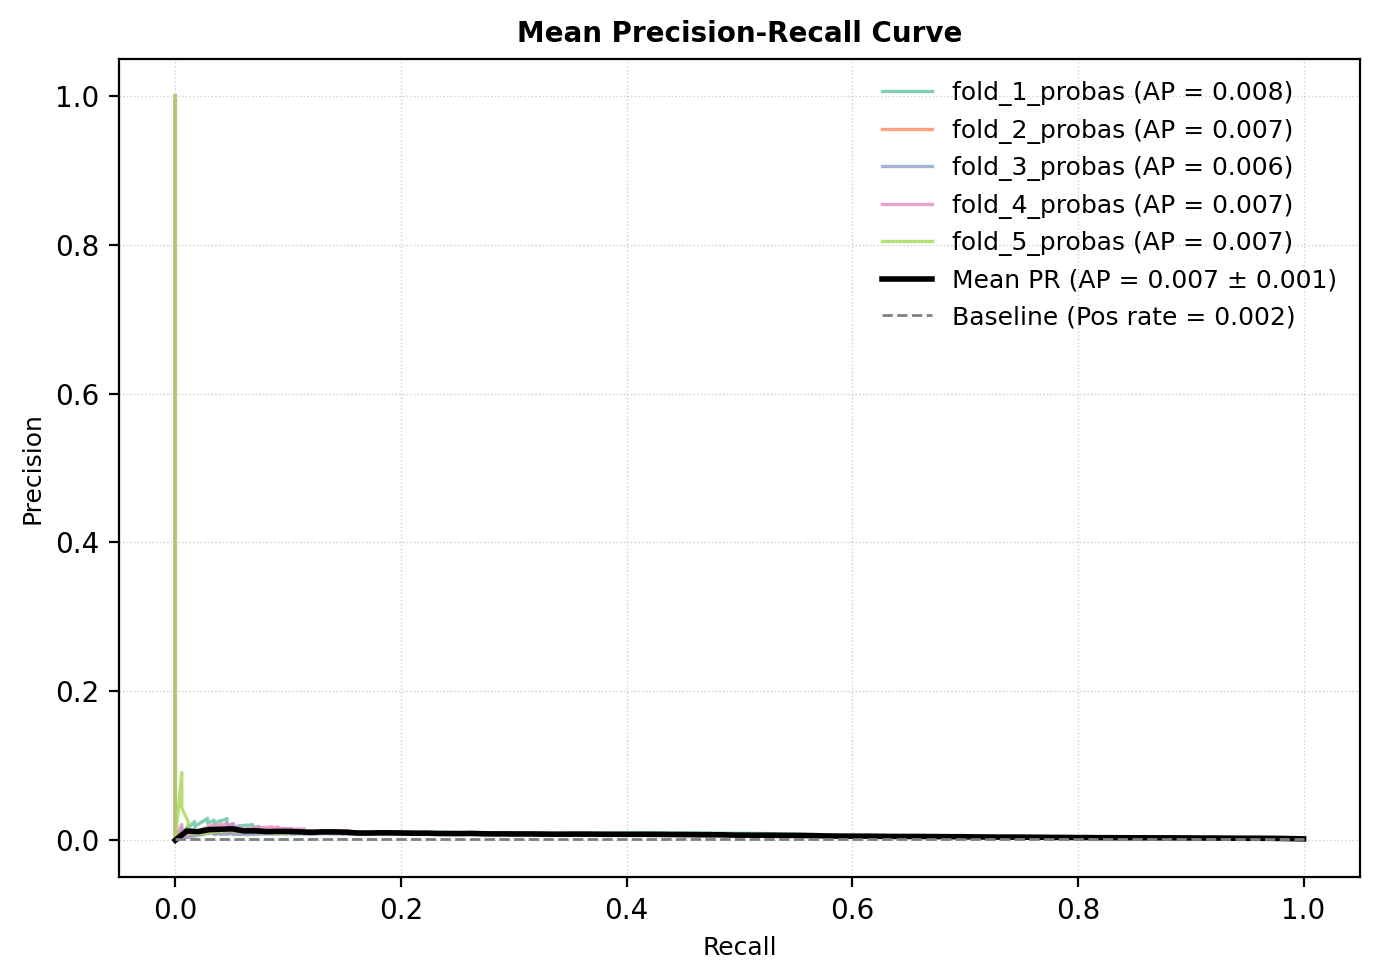

In [72]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fold_cols = [f"fold_{i}_probas" for i in range(1, 6)]
y_true = df["target"].values
mean_recall = np.linspace(0, 1, 100)

precisions = []
aps = []
colors = sns.color_palette("Set2", n_colors=len(fold_cols))

plt.figure(figsize=(7, 5), dpi=200)

for i, fold_col in enumerate(fold_cols):
    y_pred = df[fold_col].values
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    ap = average_precision_score(y_true, y_pred)
    aps.append(ap)

    # معکوس برای صعودی شدن recall
    interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
    precisions.append(interp_precision)

    # رسم هر منحنی
    plt.plot(recall, precision, lw=1.2, alpha=0.8, color=colors[i],
             label=f"{fold_col} (AP = {ap:.3f})")

# میانگین‌گیری روی همه‌ی خطوط
mean_precision = np.mean(precisions, axis=0)
mean_ap = np.mean(aps)
std_ap = np.std(aps)

# منحنی میانگین
plt.plot(mean_recall, mean_precision, color='black', lw=2,
         label=f"Mean PR (AP = {mean_ap:.3f} ± {std_ap:.3f})")

# baseline
pos_rate = np.mean(y_true)
plt.hlines(pos_rate, 0, 1, linestyles="--", colors="gray", lw=1,
           label=f"Baseline (Pos rate = {pos_rate:.3f})")

# نهایی‌سازی
plt.xlabel("Recall", fontsize=9)
plt.ylabel("Precision", fontsize=9)
plt.title("Mean Precision-Recall Curve", fontsize=10, fontweight='bold')
plt.grid(True, linestyle=':', linewidth=0.5, alpha=0.6)
plt.legend(loc="upper right", fontsize=9, frameon=False)
plt.tight_layout()
plt.show()
